## This script is used to check the QSO cutsky and lightcone mocks

In [1]:
import os, sys
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
import numpy as np
import healpy as hp
from pathlib import Path
from mockfactory import Catalog
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import lsstypes as types
sys.path.append('../../')
from plotting_tools import plot_moll

from cat_tools import get_catalog_fn, get_measurement_fn, read_positions_weights
from fit_tools import read_data_from_fn

%load_ext autoreload
%autoreload 2

## QSO lightcone mocks

In [2]:
version = 'AbacusHF-4snap' # AbacusHF-4snap, AbacusHF-v2
domain = 'lightcone' # lightcone or cutsky
hod = 'base' # base, base_dv
zsnap = 1.4
zrange = (0.8, 2.1)
data_args = dict(version=version, domain=domain, tracer='QSO', zsnap=zsnap, zrange=zrange, mock_id=0, hod=hod)
ran_args = data_args.copy()
ran_args.update(random=True, nran=None)

data_fn = get_catalog_fn(**data_args)
ran_fn = get_catalog_fn(**ran_args)

lightcone_data = Catalog.read(data_fn)
random = Catalog.read(ran_fn)

[000000.17]  06-23 05:36  FileStack                    INFO     Reading /global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-4snap/lightcone/QSO/AbacusSummit_base_c000_ph000/lightcone_AbacusHF-4snap_base_QSO_0p8to2p1_ph000.dat.fits.
[000000.29]  06-23 05:36  FileStack                    INFO     Reading /global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-4snap/lightcone/random/rands_AbacusHF-4snap_QSO_0p8to2p1.ran.fits.


In [3]:
lightcone_data

Catalog(csize=1820705, size=1820705, columns=['RA', 'DEC', 'Z', 'Z_COSMO', 'NZ', 'STATUS', 'RAN_NUM_0_1', 'WEIGHT'])

## QSO cutsky mocks

In [12]:
version = 'AbacusHF-v2' # AbacusHF-4snap, AbacusHF-v2
domain = 'cutsky' # lightcone or cutsky
hod = 'base_dv' # base, base_dv
zsnap = 1.4
zrange = (0.8, 2.1)
data_args = dict(version=version, domain=domain, tracer='QSO', zsnap=zsnap, zrange=zrange, mock_id=0, hod=hod)
ran_args = data_args.copy()
ran_args.update(random=True, nran=None)

data_fn = get_catalog_fn(**data_args)
ran_fn = get_catalog_fn(**ran_args)

cutsky_data = Catalog.read(data_fn)
random = Catalog.read(ran_fn)
cutsky_data

[000048.31]  06-22 06:30  FileStack                    INFO     Reading /global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/cutsky_AbacusHF-v2_z1p400_base_dv_QSO_0p8to2p1_ph000.dat.fits.
[000048.32]  06-22 06:30  FileStack                    INFO     Reading /global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/cutsky/random/rands_AbacusHF-v2_z1p400_QSO_0p8to2p1.ran.fits.


Catalog(csize=1817122, size=1817122, columns=['RA', 'DEC', 'Z', 'Z_COSMO', 'Z_VSMEAR', 'NZ', 'STATUS', 'RAN_NUM_0_1', 'WEIGHT'])

In [13]:
len(random)/len(cutsky_data)

12.522821252508088

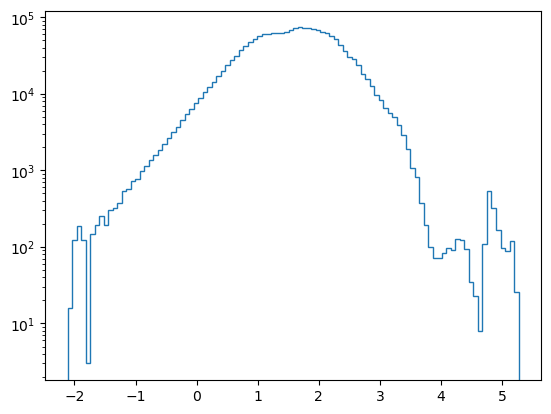

In [89]:
dz = cutsky_data['Z_VSMEAR'] - cutsky_data['Z']
CSPEED = 299792.458
dv = dz*CSPEED/(1+cutsky_data['Z']) 
dv = np.abs(dv)
mask = np.isfinite(dv) & (dv > 0)
dv_log = np.log10(dv[mask])

plt.hist(dv_log, bins=100, histtype='step')
plt.yscale('log')

/global/u1/s/shengyu/Y3/desi_y3_redshift_errors/main/mocks/notebooks/../../plotting_tools.py:278: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(<MollweideAxes: xlabel='R.A. [deg]', ylabel='Dec. [deg]'>,
 <matplotlib.collections.QuadMesh at 0x7f07505d9ea0>)

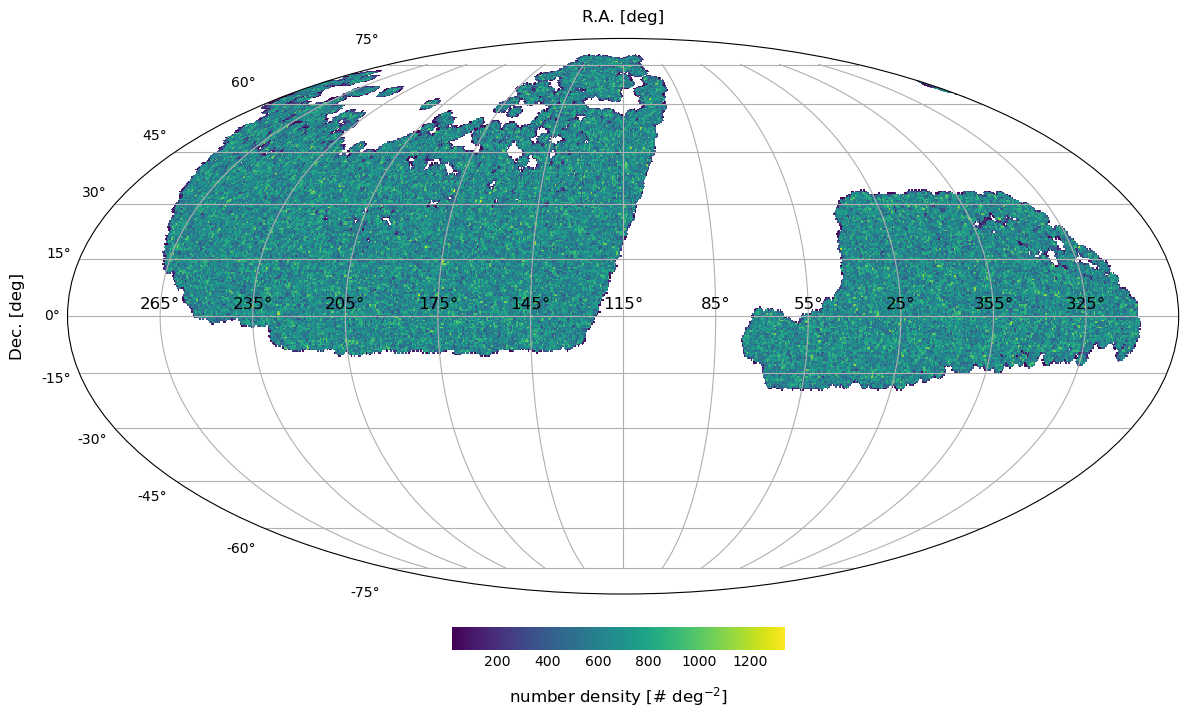

In [11]:
ra = np.asarray(data['RA'])
dec = np.asarray(data['DEC'])

nside = 128
pix = hp.ang2pix(nside, ra, dec, lonlat=True, nest=False)
hp_map = np.bincount(pix, weights=None, minlength=hp.nside2npix(nside)) * 1.0
hp_map = hp_map / hp.nside2pixarea(nside, degrees=True)

plot_moll(hp_map, title ='DR2 QSO lightcone mocks')

[000104.74]  06-12 02:31  FileStack                    INFO     Reading /global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/QSO_clustering.dat.fits.


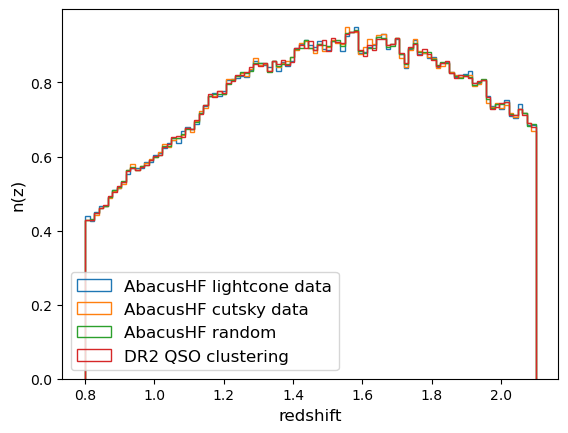

In [33]:
lightcone_data_z = np.asarray(lightcone_data['Z'])
cutsky_data_z = np.asarray(cutsky_data['Z'])
random_z = np.asarray(random['Z'])

dr2_data_fn = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP/QSO_clustering.dat.fits'
dr2_z = np.asarray(Catalog.read(dr2_data_fn)['Z'])

bins = np.linspace(0.8, 2.1, 100)
plt.hist(lightcone_data_z, bins=bins, histtype='step', density=True, alpha=1, label='AbacusHF lightcone data')
plt.hist(cutsky_data_z, bins=bins, histtype='step', density=True, alpha=1, label='AbacusHF cutsky data')
plt.hist(random_z, bins=bins, histtype='step', density=True, alpha=1, label='AbacusHF random')
plt.hist(dr2_z, bins=bins, histtype='step', density=True, alpha=1, label='DR2 QSO clustering')
plt.ylabel('n(z)', fontsize=12)
plt.xlabel('redshift', fontsize=12)
plt.legend(loc=3, fontsize=12)

## lightcone clustering

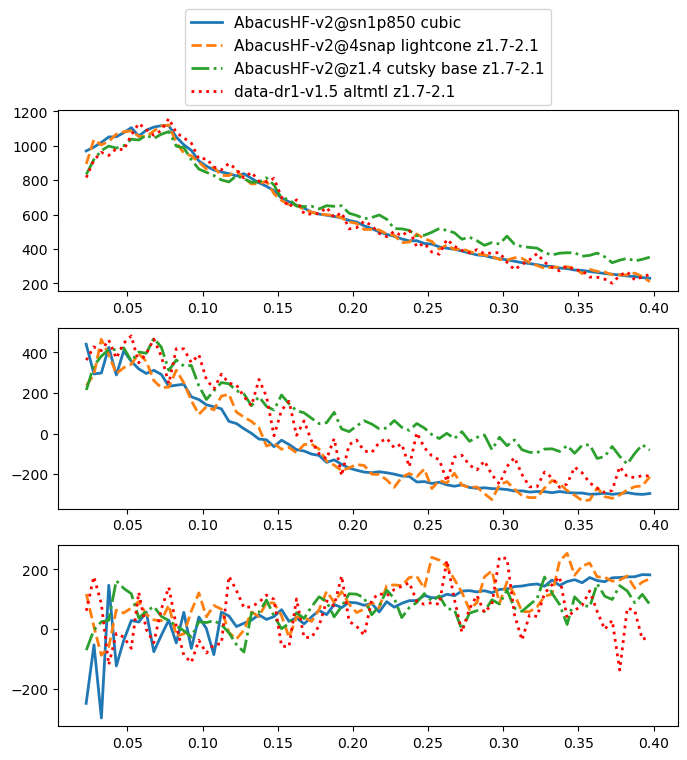

In [2]:
zrangs = [(0.8, 1.1), (1.1, 1.4), (1.4, 1.7), (1.7, 2.1)]
zsnaps = ['sn0p950', 'sn1p250', 'sn1p550', 'sn1p850']

inds = [3]
zrangs = [zrangs[i] for i in inds]
zsnaps = [zsnaps[i] for i in inds]

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(3, 1, wspace=0.05)

colors = plt.cm.tab10.colors

for iz, znap in enumerate(zsnaps):
    color = colors[iz+2]
    cubic_fn = f'/global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/boxes/QSO/{znap}/AbacusSummit_base_c000_ph000/mpspk/{{}}_QSO_zp{znap[2:].replace("p", ".")}_DR2_v2.0.h5'
    (k,pk), _ = read_data_from_fn(cubic_fn, 'mesh2', bin_type='kmax0.4')
    for ill in range(3):
        ax = plt.subplot(gs[ill])
        ax.plot(k, k*pk[ill], label=f'AbacusHF-v2@{znap} cubic ', ls = '-', lw=2)

for iz,zrange in enumerate(zrangs):
    version = 'AbacusHF-4snap' # AbacusHF-4snap, AbacusHF-v2
    domain = 'lightcone' # lightcone or cutsky
    data_args = dict(version=version, domain=domain, tracer='QSO', zsnap=zsnaps[iz], zrange=zrange, mock_id=0, hod='base')
    color = colors[iz+5]
    fn = get_measurement_fn(**data_args)
    (k,pk), _ = read_data_from_fn(fn, 'mesh2', bin_type='kmax0.4')
    for ill in range(3):
        ax = plt.subplot(gs[ill])
        ax.plot(k, k*pk[ill], label=f'AbacusHF-v2@4snap lightcone z{zrange[0]}-{zrange[1]}', ls = '--', lw=2)

for iz,zrange in enumerate(zrangs):
    version = 'AbacusHF-v2' # AbacusHF-4snap, AbacusHF-v2
    domain = 'cutsky' # lightcone or cutsky
    data_args = dict(version=version, domain=domain, tracer='QSO', zsnap=zsnaps[iz], zrange=zrange, mock_id=0, hod='base')
    color = colors[iz+5]
    fn = get_measurement_fn(**data_args)
    (k,pk), _ = read_data_from_fn(fn, 'mesh2', bin_type='kmax0.4')
    for ill in range(3):
        ax = plt.subplot(gs[ill])
        ax.plot(k, k*pk[ill], label=f'AbacusHF-v2@z1.4 cutsky base z{zrange[0]}-{zrange[1]}', ls = '-.', lw=2)

for iz,zrange in enumerate(zrangs):
    version = 'data-dr1-v1.5' # AbacusHF-4snap, AbacusHF-v2
    domain = 'altmtl' # lightcone or cutsky
    data_args = dict(version=version, domain=domain, tracer='QSO', zsnap=zsnaps[iz], zrange=zrange, mock_id=0, region='GCcomb', hod='base')
    color = colors[iz+5]
    fn = get_measurement_fn(**data_args)
    (k,pk), _ = read_data_from_fn(fn, 'mesh2', bin_type='kmax0.4')
    for ill in range(3):
        ax = plt.subplot(gs[ill])
        ax.plot(k, k*pk[ill], label=f'data-dr1-v1.5 altmtl z{zrange[0]}-{zrange[1]}', ls = ':', lw=2, color = 'red')

ax = plt.subplot(gs[0])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.6), fontsize=11, ncol =1)

## comapred with the DR1 data

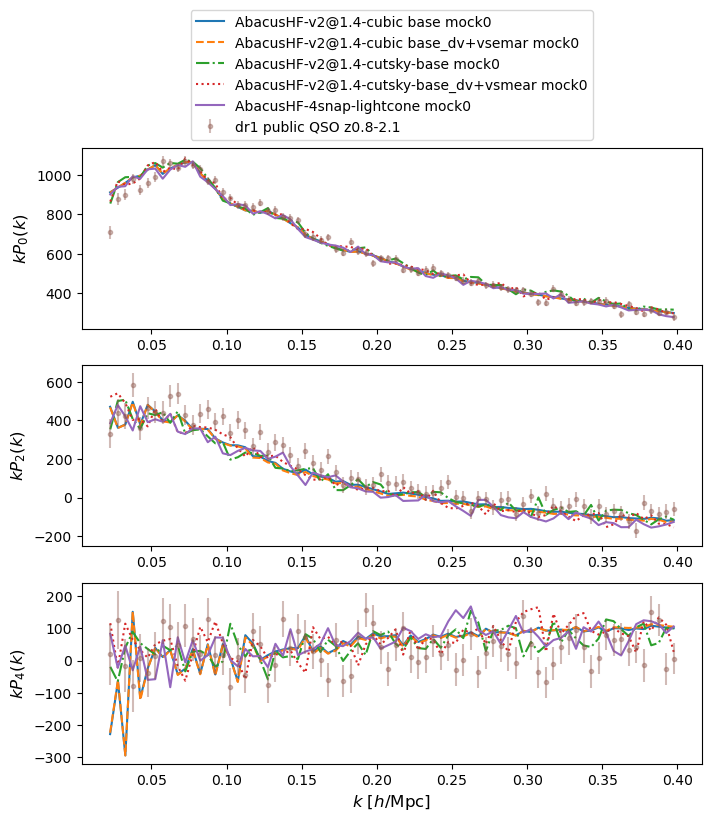

In [103]:
from unittest import result

BASE_DIR = '/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'
MOCK_DIR = '/global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3'


fn_hf_cubic_base = [f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/mock_challenge/abacushf_MC/v2/QSO/mesh2_spectrum_poles_QSO_z1.400_c000_hod-base_los-z_0.h5', 'AbacusHF-v2@1.4-cubic base mock0']
fn_hf_cubic_base_dv_vsmear = [f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/mock_challenge/abacushf_MC/v2/QSO/mesh2_spectrum_poles_QSO_z1.400_c000_hod-base_dv_los-z_0.h5', 'AbacusHF-v2@1.4-cubic base_dv+vsemar mock0']

fn_hf_cutsky_base = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base.h5', 'AbacusHF-v2@1.4-cutsky-base mock0']
fn_hf_cutsky_base_dv_vsmear = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base_dv+dv_vsmear.h5', 'AbacusHF-v2@1.4-cutsky-base_dv+vsmear mock0']
fn_hf_cutsky_base_dv_nonparam = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base_dv+dv_verr_nonparam.h5', 'AbacusHF-v2@1.4-cutsky-base_dv+dv_nonparam mock0']

fn_hf_lightcone_dv = [f'{MOCK_DIR}/AbacusHF-4snap/lightcone/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_4snap_base.h5', 'AbacusHF-4snap-lightcone mock0']


# fn_hf_cutsky_base_dv_vsmear = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base.h5', 'AbacusHF-v2@1.4-cutsky-base mock0']

# fn_hf_cutsky_base_dv_novsmear = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base.h5', 'AbacusHF-v2@1.4-cutsky-base mock0']

fn_dr1_v15 = [f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/base/data-dr1-v1.5/mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP.h5', 'dr1 v1.5 QSO z0.8-2.1']
fn_public_dr1 = ['/global/cfs/cdirs/desi/public/dr1/vac/dr1/full-shape-bao-clustering/v1.0/data/spectrum/spectrum-poles_QSO_GCcomb_z0.8-2.1.h5', 'dr1 public QSO z0.8-2.1']
cov_fn_public_dr1 = '/global/cfs/cdirs/desi/public/dr1/vac/dr1/full-shape-bao-clustering/v1.0/data/covariance/EZmock/covariance_spectrum-poles_QSO_GCcomb_z0.8-2.1.h5'

# fns = [fn_hf_cubic_base, fn_hf_cubic_base_dv_vsmear, fn_hf_cutsky_base, fn_hf_cutsky_base_dv_nonparam, fn_hf_lightcone_dv, fn_public_dr1]

fns = [ fn_hf_cubic_base, fn_hf_cubic_base_dv_vsmear, fn_hf_cutsky_base, fn_hf_cutsky_base_dv_vsmear, fn_hf_lightcone_dv, fn_public_dr1]

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(3, 1, wspace=0.05)
def read_mean_mesh2(fn_template, mock_ids):
    ks = []
    pks = []
    used = []
    for mock_id in mock_ids:
        fn = fn_template.format(mock_id=mock_id)
        if not os.path.exists(fn):
            # print(f'missing {fn}')
            continue
        (k, pk), _ = read_data_from_fn(fn, 'mesh2', bin_type='kmax0.4')
        ks.append(np.asarray(k))
        pks.append(np.asarray(pk))
        used.append(mock_id)
    if not pks:
        raise FileNotFoundError(f'No mock files found for {fn_template}')
    return ks[0], np.mean(pks, axis=0)

lss = ['-', '--', '-.', ':', '-', ':']
for ill in [0,1, 2]:
    ax = plt.subplot(gs[ill])
    for f, (fn, label) in enumerate(fns):
        mock_ids = [1]
        if 'public' in label:
            data = types.read(fn)
            data = data.select(k=slice(0, None, 5)).select(k=(0.02, 0.4))
            k = data.get(ells=0).coords('k')
            Pk = [data.get(ells=ell).values()['value'] for ell in data.ells]
            cov=types.read(cov_fn_public_dr1)
            cov = cov.at.observable.match(data)
            err = np.asarray(cov.std())
            errs = np.split(err, 3)
            # ax.plot(k, k*Pk[ill], color=f'C{f}', label=label)
            ax.errorbar(k, k*Pk[ill], yerr=k*errs[ill], markersize=3, fmt='o', color=f'C{f}', alpha=0.4, label=label)
        else:
            if fn.endswith('.h5'):
                (k, pk) = read_mean_mesh2(fn, mock_ids=mock_ids)
            else:
                k, p0, p2, p4 = np.loadtxt(fn, unpack=True)
                pk = [p0, p2, p4]
            ax.plot(k, k*pk[ill], color = f'C{f}', ls =lss[f], label = label, lw=1.5)
    if ill==0:
        ax.set_ylabel('$k P_0(k)$', fontsize=12)
    if ill==1:
        ax.set_ylabel('$k P_2(k)$', fontsize=12)
    if ill==2:
        ax.set_ylabel('$k P_4(k)$', fontsize=12)
        ax.set_xlabel('$k$ [$h$/Mpc]', fontsize=12)

ax = plt.subplot(gs[0])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2+0.1*len(fns)), fontsize=10)

## Check the cutsky with cubic

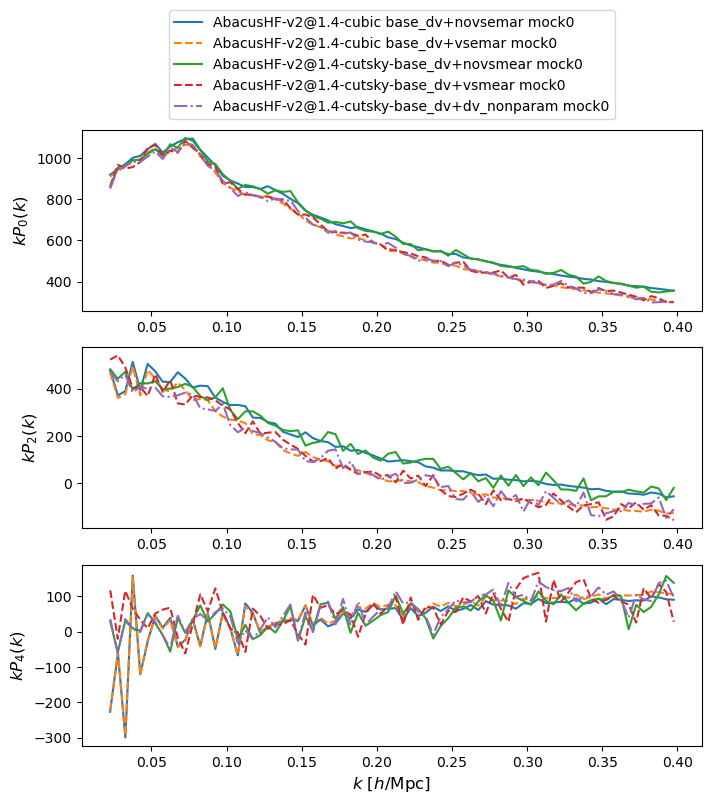

In [15]:
from unittest import result

BASE_DIR = '/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base'
MOCK_DIR = '/global/cfs/cdirs/desi/users/shengyu/galaxies/catalogs/Y3'

fn_hf_cubic_base = [f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/mock_challenge/abacushf_MC/v2/QSO/mesh2_spectrum_poles_QSO_z1.400_c000_hod-base_los-z_0.h5', 'AbacusHF-v2@1.4-cubic base mock0']
fn_hf_cubic_base_dv_vsmear = [f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/mock_challenge/abacushf_MC/v2/QSO/mesh2_spectrum_poles_QSO_z1.400_c000_hod-base_dv_los-z_0.h5', 'AbacusHF-v2@1.4-cubic base_dv+vsemar mock0']
fn_hf_cubic_base_dv_novsmear = [f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/mock_challenge/abacushf_MC/v2/QSO/mesh2_spectrum_poles_QSO_z1.400_c000_hod-base_dv_los-z_novsmear_0.h5', 'AbacusHF-v2@1.4-cubic base_dv+novsemar mock0']

fn_hf_cutsky_base = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base.h5', 'AbacusHF-v2@1.4-cutsky-base mock0']
fn_hf_cutsky_base_dv_vsmear = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base_dv+dv_vsmear.h5', 'AbacusHF-v2@1.4-cutsky-base_dv+vsmear mock0']
fn_hf_cutsky_base_dv_novsmear = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base_dv.h5', 'AbacusHF-v2@1.4-cutsky-base_dv+novsmear mock0']
fn_hf_cutsky_base_dv_nonparam = [f'{MOCK_DIR}/AbacusHF-v2/cutsky/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_v2.0_base_dv+dv_verr_nonparam.h5', 'AbacusHF-v2@1.4-cutsky-base_dv+dv_nonparam mock0']

# fn_hf_lightcone_dv = [f'{MOCK_DIR}/AbacusHF-4snap/lightcone/QSO/AbacusSummit_base_c000_ph000/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_hf_4snap_base.h5', 'AbacusHF-4snap-lightcone mock0']


# fns = [fn_base_AbacusHF, fn_base_abacus_2nd, fn_base_holi, fn_base_glum, fn_public_dr1]

fns = [fn_hf_cubic_base_dv_novsmear, fn_hf_cubic_base_dv_vsmear, fn_hf_cutsky_base_dv_novsmear, fn_hf_cutsky_base_dv_vsmear, fn_hf_cutsky_base_dv_nonparam]
# fns = [fn_hf_cubic_base, fn_hf_cubic_base_dv_vsmear, fn_hf_cutsky_base, fn_hf_cutsky_base_dv_vsmear]

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(3, 1, wspace=0.05)

def read_mean_mesh2(fn_template, mock_ids):
    ks = []
    pks = []
    used = []
    for mock_id in mock_ids:
        fn = fn_template.format(mock_id=mock_id)
        if not os.path.exists(fn):
            # print(f'missing {fn}')
            continue
        (k, pk), _ = read_data_from_fn(fn, 'mesh2', bin_type='kmax0.4')
        ks.append(np.asarray(k))
        pks.append(np.asarray(pk))
        used.append(mock_id)
    if not pks:
        raise FileNotFoundError(f'No mock files found for {fn_template}')
    return ks[0], np.mean(pks, axis=0)

lss = ['-', '--', '-', '--', '-.']
for ill in [0,1,2]:
    ax = plt.subplot(gs[ill])
    for f, (fn, label) in enumerate(fns):
        mock_ids = [1]
        if fn.endswith('.h5'):
            (k, pk) = read_mean_mesh2(fn, mock_ids=mock_ids)
        else:
            k, p0, p2, p4 = np.loadtxt(fn, unpack=True)
            pk = [p0, p2, p4]
        ax.plot(k, k*pk[ill], color = f'C{f}', ls =lss[f], label = label)
    if ill==0:
        ax.set_ylabel('$k P_0(k)$', fontsize=12)
    if ill==1:
        ax.set_ylabel('$k P_2(k)$', fontsize=12)
    if ill==2:
        ax.set_ylabel('$k P_4(k)$', fontsize=12)
        ax.set_xlabel('$k$ [$h$/Mpc]', fontsize=12)

ax = plt.subplot(gs[0])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2+0.1*len(fns)), fontsize=10)

array([[ 1.26269887e+10, -8.71371184e+09, -1.58898604e+09,
         1.83149280e+09,  1.93920773e+09,  2.04938974e+09,
         1.44995878e+09,  9.25400026e+08,  9.45049280e+08,
         7.55740187e+08,  6.09498603e+08,  4.86195921e+08,
         3.97886140e+08,  3.38257425e+08,  3.13049311e+08,
         3.02880194e+08,  2.35265472e+08,  1.91128777e+08,
         1.61295607e+08,  1.35246102e+08,  1.15951137e+08,
         1.06896475e+08,  9.15994342e+07,  8.59634174e+07,
         7.39808115e+07,  7.48238510e+07,  6.28482943e+07,
         5.48595217e+07,  4.85246853e+07,  4.46019780e+07,
         3.70491995e+07,  3.36914011e+07,  2.89613135e+07,
         2.74242585e+07,  2.50932291e+07,  2.35002367e+07,
         2.13532544e+07,  2.02616551e+07,  1.81472411e+07,
         1.65210023e+07],
       [ 4.38050279e+10, -1.97057916e+10,  1.00211269e+09,
        -3.85940861e+09,  1.85344773e+09,  1.35740082e+09,
         5.13880742e+08,  7.53464275e+08,  3.36154021e+08,
         2.94165621e+08,  2.91